# ML Assignment — STEP 0: Shared Data Preprocessing
## Dataset: FIFA Players Dataset (Sports/Entertainment)

---
**ALL 4 MEMBERS must run this notebook FIRST before running their own notebooks.**

This notebook:
- Downloads the dataset
- Cleans and preprocesses it
- Saves a cleaned file that all 4 members use

**Dataset:** FIFA Players Statistics
**Source:** https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset

**Goal:** Predict whether a player is an ATTACKER, MIDFIELDER, or DEFENDER based on their stats.

---

## Step 1: Install required libraries
Run this once. If they are already installed, it won't cause any problem.

In [84]:
# Run this cell first to install everything needed
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn', 
                'matplotlib', 'seaborn', 'openpyxl'], 
               capture_output=True)
print('All libraries ready!')

All libraries ready!


## Step 2: Import libraries

In [85]:
# Import all the tools we need
import pandas as pd          # For handling data tables
import numpy as np           # For numbers and math
import matplotlib.pyplot as plt  # For drawing graphs
import seaborn as sns        # For nicer graphs
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 3: Load the dataset

**HOW TO GET THE DATASET:**
1. Go to: https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset
2. Click 'Download'
3. You will get a zip file — extract it
4. Look for the file called `players_22.csv`
5. Put it in the SAME folder as this notebook
6. Then run the cell below

In [86]:
# Load the dataset
# Make sure players_22.csv is in the same folder as this notebook!
df = pd.read_csv('players_22.csv', low_memory=False)

print('Dataset loaded!')
print(f'Number of rows (players): {df.shape[0]}')
print(f'Number of columns (attributes): {df.shape[1]}')

Dataset loaded!
Number of rows (players): 19239
Number of columns (attributes): 110


## Step 4: Explore the data

## Step 5: Select useful columns

We pick only the columns that are relevant to predict a player's position.

## Step 6: Create the target label (position category)

We will simplify positions into 3 groups:
- **ATTACKER** — ST, CF, LW, RW, CAM
- **MIDFIELDER** — CM, CDM, LM, RM
- **DEFENDER** — CB, LB, RB, LWB, RWB, GK

## Step 7: Clean the data

## Step 8: Visualize the data

## Step 9: Prepare features (X) and labels (y)

## Step 10: Scale the features

Scaling makes all numbers be in a similar range (e.g. age=25 and height=180 become comparable).
This helps most ML algorithms work better.

## Step 11: Split into Training and Testing sets

- **80% Training data** — the model learns from this
- **20% Test data** — we test accuracy on this (model has never seen it)

## Step 12: Save the cleaned data

**This is very important!** All 4 members will load this same saved file.
This ensures everyone uses identical data.

In [ ]:
import numpy as np

# Save everything to files that all members will use
np.save('X_train.npy', X_train)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy',  y_test)

# Also save the label names so members can decode predictions
np.save('class_names.npy', le.classes_)

# Save the cleaned CSV too
df_clean.to_csv('players_cleaned.csv', index=False)

print('All files saved successfully!')
print('Files created:')
print('  X_train.npy   — training features')
print('  X_test.npy    — test features')
print('  y_train.npy   — training labels')
print('  y_test.npy    — test labels')
print('  class_names.npy — position names')
print('  players_cleaned.csv — full cleaned dataset')
print()
print('NOW share these files with all 4 members before they run their notebooks!')

All files saved successfully!
Files created:
  X_train.npy   — training features
  X_test.npy    — test features
  y_train.npy   — training labels
  y_test.npy    — test labels
  class_names.npy — position names
  players_cleaned.csv — full cleaned dataset

NOW share these files with all 4 members before they run their notebooks!


In [ ]:
# Split data: 80% train, 20% test
# random_state=42 means everyone gets the SAME split (important for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Data split done!')
print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

Data split done!
Training samples: 13685
Testing samples:  3422
After SMOTE:
0    5115
2    5115
1    5115
Name: count, dtype: int64


In [ ]:
# Scale features so they are all on similar scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features scaled successfully!')
print(f'Before scaling - first row sample: {X[0]}')
print(f'After scaling  - first row sample: {X_scaled[0].round(2)}')

Features scaled successfully!
Before scaling - first row sample: [ 34. 170.  72.  93.  93.  85.  92.  91.  95.  34.  65.]
After scaling  - first row sample: [ 1.93 -1.59 -0.31  4.    3.6   1.54  2.82  3.35  3.36 -1.09  0.02]


In [ ]:
# X = the input features (what the model learns from)
X = df_clean[feature_cols].values

# y = the labels (what we want to predict)
# We convert text labels to numbers: ATTACKER=0, DEFENDER=1, MIDFIELDER=2
le = LabelEncoder()
y = le.fit_transform(df_clean['position_category'])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} = {i}')

print(f'\nX shape: {X.shape}  (rows=players, columns=features)')
print(f'y shape: {y.shape}  (one label per player)')

Label encoding:
  ATTACKER = 0
  DEFENDER = 1
  MIDFIELDER = 2

X shape: (17107, 11)  (rows=players, columns=features)
y shape: (17107,)  (one label per player)


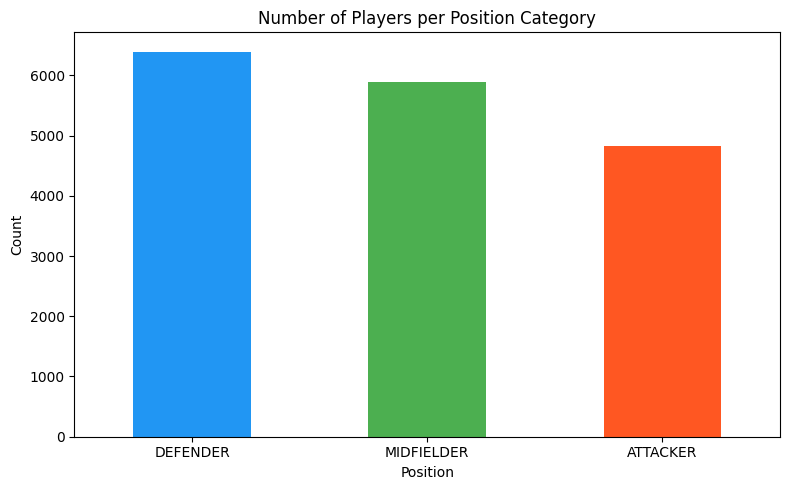

Chart saved as plot_class_distribution.png


In [ ]:
# Bar chart: how many players per category
plt.figure(figsize=(8, 5))
df_clean['position_category'].value_counts().plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF5722'])
plt.title('Number of Players per Position Category')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_class_distribution.png')  # Save for the report
plt.show()
print('Chart saved as plot_class_distribution.png')

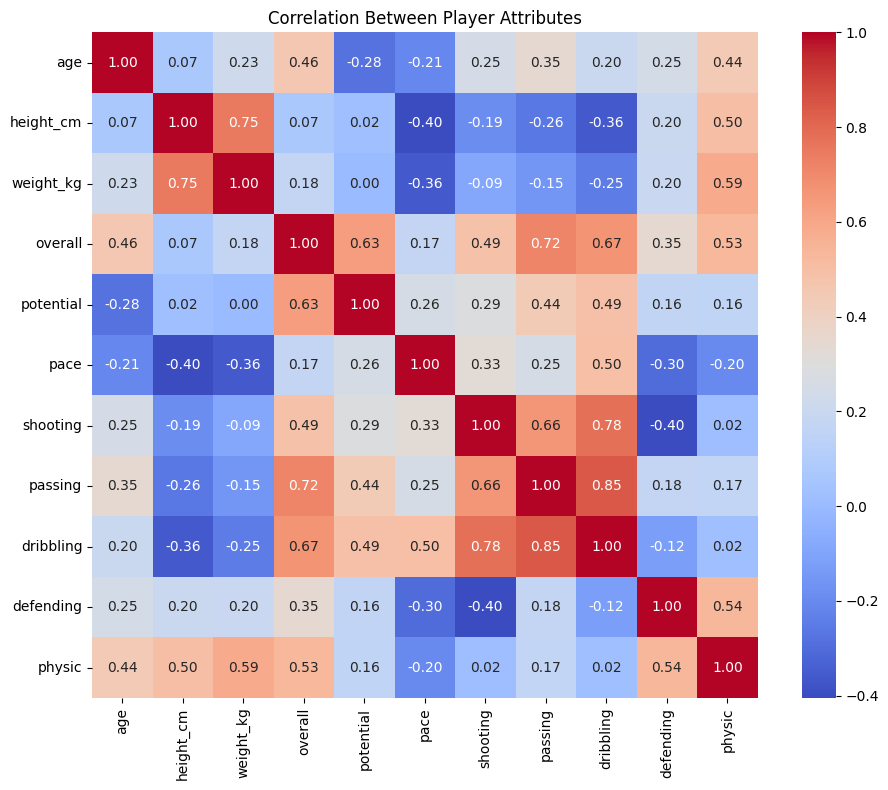

Heatmap saved as plot_correlation_heatmap.png


In [ ]:
# Heatmap: correlation between features
plt.figure(figsize=(10, 8))
corr = df_clean[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Between Player Attributes')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png')  # Save for the report
plt.show()
print('Heatmap saved as plot_correlation_heatmap.png')

In [ ]:
# Drop rows where position is unknown
df_clean = df_selected.dropna(subset=['position_category']).copy()

# Drop rows where any feature column has missing values
feature_cols = ['age', 'height_cm', 'weight_kg', 'overall', 'potential',
                'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

df_clean = df_clean.dropna(subset=feature_cols)

print(f'Rows after cleaning: {len(df_clean)}')
print(f'Rows removed: {len(df_selected) - len(df_clean)}')
print('\nPosition counts after cleaning:')
print(df_clean['position_category'].value_counts())

Rows after cleaning: 17107
Rows removed: 2132

Position counts after cleaning:
position_category
DEFENDER      6394
MIDFIELDER    5882
ATTACKER      4831
Name: count, dtype: int64


In [ ]:
# Function to categorize position
def categorize_position(pos_str):
    if pd.isna(pos_str):
        return None
    # Take the FIRST position listed (players can have multiple)
    first_pos = str(pos_str).split(',')[0].strip()
    
    attackers  = ['ST', 'CF', 'LW', 'RW', 'CAM', 'LS', 'RS', 'SS']
    midfielders = ['CM', 'CDM', 'LM', 'RM', 'LAM', 'RAM', 'LCM', 'RCM', 'LDM', 'RDM']
    defenders  = ['CB', 'LB', 'RB', 'LWB', 'RWB', 'GK', 'LCB', 'RCB', 'RES', 'SUB']
    
    if first_pos in attackers:
        return 'ATTACKER'
    elif first_pos in midfielders:
        return 'MIDFIELDER'
    elif first_pos in defenders:
        return 'DEFENDER'
    else:
        return None  # Unknown position — will be dropped

# Apply categorization
df_selected['position_category'] = df_selected['player_positions'].apply(categorize_position)

# Show how many of each
print('Player count by position category:')
print(df_selected['position_category'].value_counts())

Player count by position category:
position_category
DEFENDER      8526
MIDFIELDER    5882
ATTACKER      4831
Name: count, dtype: int64


In [ ]:
# Select useful columns for our ML task
columns_to_use = [
    'short_name',        # Player name (just for reference, we won't train on this)
    'age',               # Player age
    'height_cm',         # Player height
    'weight_kg',         # Player weight
    'overall',           # Overall rating
    'potential',         # Potential rating
    'pace',              # Speed
    'shooting',          # Shooting ability
    'passing',           # Passing ability
    'dribbling',         # Dribbling ability
    'defending',         # Defending ability
    'physic',            # Physical strength
    'player_positions',  # Player's positions (this is our TARGET/label)
]

# Keep only these columns
df_selected = df[columns_to_use].copy()

print(f'Selected {len(columns_to_use)} columns')
df_selected.head()

Selected 13 columns


,short_name,age,height_cm,weight_kg,overall,potential,pace,shooting,passing,dribbling,defending,physic,player_positions
0,L. Messi,34,170,72,93,93,85.0,92.0,91.0,95.0,34.0,65.0,"RW, ST, CF"
1,R. Lewandowski,32,185,81,92,92,78.0,92.0,79.0,86.0,44.0,82.0,ST
2,Cristiano Ronaldo,36,187,83,91,91,87.0,94.0,80.0,88.0,34.0,75.0,"ST, LW"
3,Neymar Jr,29,175,68,91,91,91.0,83.0,86.0,94.0,37.0,63.0,"LW, CAM"
4,K. De Bruyne,30,181,70,91,91,76.0,86.0,93.0,88.0,64.0,78.0,"CM, CAM"


In [ ]:
# Look at the first 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [ ]:
# See all column names
print('All column names:')
print(df.columns.tolist())

All column names:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movemen

In [ ]:
# Check data types and missing values
print('Data types and missing value count:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

Data types and missing value count:
sofifa_id           int64
player_url            str
short_name            str
long_name             str
player_positions      str
                    ...  
player_face_url       str
club_logo_url         str
club_flag_url         str
nation_logo_url       str
nation_flag_url       str
Length: 110, dtype: object

Missing values per column:
sofifa_id               0
player_url              0
short_name              0
long_name               0
player_positions        0
                    ...  
player_face_url         0
club_logo_url          61
club_flag_url          61
nation_logo_url     18480
nation_flag_url         0
Length: 110, dtype: int64
